# Decision tree

## Imports

In [1]:
import mlflow
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.tree import export_text

from heart_failure.modeling.models import build_dt_pipeline
from heart_failure.features import get_fe_pipeline
from heart_failure.dataset import split_data
from heart_failure.modeling.train import optuna_search, dt_space
from heart_failure.config.modeling import CV_SPLITS, OPTUNA_N_TRIALS, LR_SCORING, F_BETA_THRESHOLD
from heart_failure.config.config import INTERIM_DATA_DIR, HEART_DISEASE, SEX, PROCESSED_DATA_DIR
from heart_failure.config.features import TEST_SIZE, RANDOM_STATE, VAL_SIZE
from heart_failure.reports import print_best_params
from heart_failure.modeling.evaluate import (
    get_metrics, log_metrics, optuna_cv_results_to_df, find_best_threshold, find_max_recall_by_pr
)
from heart_failure.modeling.predict import predict_by_threshold
from heart_failure.plots import plot_pr_curve

2026-06-18 16:33:42.178 | INFO     | heart_failure.config.config:<module>:11 - PROJ_ROOT path is: D:\heart_failure


In [2]:
MODEL_NAME = "decision_tree"
mlflow.set_experiment(f"heart_failure")

<Experiment: artifact_location='file:D:/heart_failure/notebooks/mlruns/1', creation_time=1781534399229, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1781534399229, lifecycle_stage='active', name='heart_failure', tags={}, trace_location=None, workspace='default'>

In [15]:
df = pd.read_csv(INTERIM_DATA_DIR / "heart.csv")
rem_columns = pd.read_csv(PROCESSED_DATA_DIR / "remaining_cols.csv")
rem_columns = rem_columns.squeeze().to_list()

y = df[HEART_DISEASE]
X = df.drop(columns=[HEART_DISEASE])

X_train, y_train, X_val, y_val, X_test, y_test = split_data(
    X, y, stratify_func=lambda X, y: pd.concat([X[[SEX]], y], axis=1)
)

## Training

There is no point in selecting a list of rules (features), since they are unique for each fold. Because of this, multicollinearity does not disappear from the data; accordingly, the importance can be spread across several features.

In [ ]:
fe_pipeline = get_fe_pipeline(combine_rules=False)
study, model = optuna_search(
    X_train,
    y_train,
    model_builder=build_dt_pipeline,
    param_space=dt_space,
    n_trials=OPTUNA_N_TRIALS,
    n_splits=CV_SPLITS,
    scoring=LR_SCORING,
    random_state=RANDOM_STATE,
    fe_pipeline=fe_pipeline,
)

In [21]:
print_best_params(study)

Best parameters: {'model__max_depth': 8, 'model__min_samples_leaf': 28, 'model__max_features': 'sqrt'}
Best score: 0.89861


In [22]:
optuna_cv_results_to_df(study).sort_values(["rank_test_score"]).head()

,params,std_test_score,mean_test_score,split_test_0,split_test_1,split_test_2,split_test_3,split_test_4,rank_test_score
10,"{'model__max_depth': 8, 'model__min_samples_le...",0.024552,0.898612,0.912404,0.860522,0.934179,0.888269,0.897686,1
31,"{'model__max_depth': 7, 'model__min_samples_le...",0.024552,0.898612,0.912404,0.860522,0.934179,0.888269,0.897686,1
25,"{'model__max_depth': 6, 'model__min_samples_le...",0.024552,0.898612,0.912404,0.860522,0.934179,0.888269,0.897686,1
23,"{'model__max_depth': 7, 'model__min_samples_le...",0.024552,0.898612,0.912404,0.860522,0.934179,0.888269,0.897686,1
37,"{'model__max_depth': 7, 'model__min_samples_le...",0.024552,0.898612,0.912404,0.860522,0.934179,0.888269,0.897686,1


The scores for different trials are very similar. Hyperparameters don't have that much of an impact on the results in this case.

#### Feature importance

In [23]:
tree = model.named_steps["model"]
columns = fe_pipeline.fit_transform(X_train, y_train).columns
pd.Series(tree.feature_importances_, index=columns).sort_values(ascending=False)

remainder__Oldpeak_ChestPainType_te            0.509901
remainder__MaxHR<=150 & ST_Slope=Flat          0.377601
remainder__FastingBS_ChestPainType_te          0.039349
binary_encoder__ExerciseAngina                 0.032223
target_encoder__ST_Slope                       0.022272
remainder__ChestPain=ASY & ST_Slope=Flat       0.009268
target_encoder__RestingECG                     0.003813
remainder__RestingBP                           0.001743
binarizer__MaxHR                               0.001570
remainder__MaxHR_RestingECG_te                 0.001558
remainder__Age_MaxHR_ratio                     0.000511
remainder__RestingBP_Sex_te                    0.000190
binarizer__Cholesterol                         0.000000
binarizer__Age                                 0.000000
remainder__Oldpeak>=2 & MaxHR<=150             0.000000
remainder__Oldpeak>=2 & MaxHR<=160             0.000000
remainder__Oldpeak                             0.000000
binary_encoder__Sex                            0

2 features are decisive. One is target encoding, the other is condition. Moreover, each of the features within the group is different.

#### Tree visualization

In [24]:
rules = export_text(tree, feature_names=list(fe_pipeline.transform(X_train).columns))
print(rules)

|--- remainder__Oldpeak_ChestPainType_te <= 0.62
|   |--- remainder__MaxHR<=150 & ST_Slope=Flat <= 0.50
|   |   |--- remainder__FastingBS_ChestPainType_te <= 0.49
|   |   |   |--- binarizer__MaxHR <= 6.50
|   |   |   |   |--- remainder__MaxHR_RestingECG_te <= 0.62
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- remainder__MaxHR_RestingECG_te >  0.62
|   |   |   |   |   |--- class: 0
|   |   |   |--- binarizer__MaxHR >  6.50
|   |   |   |   |--- target_encoder__ST_Slope <= 0.19
|   |   |   |   |   |--- remainder__Age_MaxHR_ratio <= 0.27
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- remainder__Age_MaxHR_ratio >  0.27
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- target_encoder__ST_Slope >  0.19
|   |   |   |   |   |--- class: 0
|   |   |--- remainder__FastingBS_ChestPainType_te >  0.49
|   |   |   |--- class: 0
|   |--- remainder__MaxHR<=150 & ST_Slope=Flat >  0.50
|   |   |--- remainder__Oldpeak_ChestPainType_te <= 0.58
|   |   |   |--- remainder__Re

Here we can also see that the class is defined by only 2 features.

### Threshold searching

In [25]:
y_train_proba = model.predict_proba(X_train)[:, 1]
best_threshold = find_best_threshold(y_train, y_train_proba, 1.5)
best_threshold

np.float64(0.293)

## Metrics

In [26]:
print("Validate metrics")
y_val_pred = predict_by_threshold(model, X_val, best_threshold)
y_val_proba = model.predict_proba(X_val)[:, 1]
val_metrics = get_metrics(y_val, y_val_pred, y_val_proba)
val_metrics

Validate metrics


precision    0.741935
recall       0.938776
f2_score     0.891473
pr_auc       0.818463
dtype: float64

The metrics are better than those of logistic regression and baseline, but pr-auc is less. At the same time, recall is closer to 1.

### Confusion Matrix

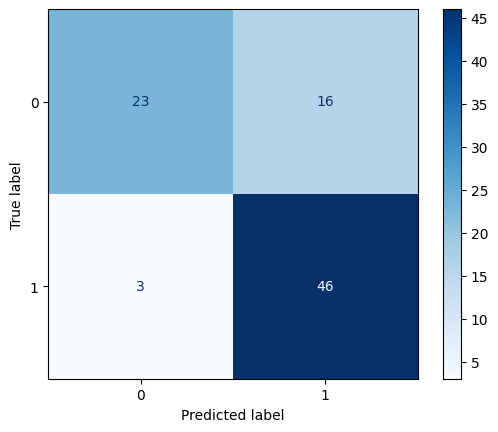

In [27]:
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred, cmap="Blues")
plt.show()

### PR-curve

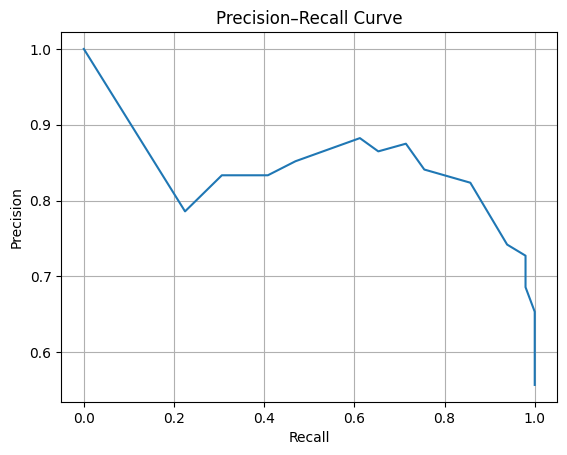

In [28]:
plot_pr_curve(y_val, y_val_proba)

In [36]:
best_threshold = find_max_recall_by_pr(y_val, y_val_proba)
round(best_threshold, 3)

np.float64(0.048)

For logistic regression the threshold was different. Here it’s practically zero. It may be better to take recall not 1, since then we will very rarely predict class 0.

In [37]:
best_threshold = find_max_recall_by_pr(y_val, y_val_proba, 2)
round(best_threshold, 3)

np.float64(0.293)

### Test metrics

In [38]:
print("Test metrics")
y_test_pred = predict_by_threshold(model, X_test, best_threshold)
y_test_proba = model.predict_proba(X_test)[:, 1]
test_metrics = get_metrics(y_test, y_test_pred, y_test_proba)
test_metrics

Test metrics


precision    0.721429
recall       0.990196
f2_score     0.921533
pr_auc       0.894434
dtype: float64

As a result, now the best option is a tree (based on validation). At the same time, the spread across folds is the same as that of logistic regression.

In [ ]:
with mlflow.start_run(run_name=MODEL_NAME) as run:
    mlflow.log_param("model", MODEL_NAME)
    mlflow.log_param("test_size", TEST_SIZE)
    mlflow.log_param("val_size", VAL_SIZE)
    mlflow.log_param("random_state", RANDOM_STATE)
    mlflow.log_param("cv_splits", CV_SPLITS)
    mlflow.log_param("optuna_n_trials", OPTUNA_N_TRIALS)
    mlflow.log_param("remaining_columns", "all")
    mlflow.log_param("f_beta_threshold", F_BETA_THRESHOLD)
    mlflow.log_param("proba_threshold", best_threshold)

    mlflow.sklearn.log_model(sk_model=model, name=MODEL_NAME)

    log_metrics(val_metrics, "val_")
    log_metrics(test_metrics, "test_")